# SIT307 8.1D — Sydney Housing Price Prediction and Decision Support System

**Saatvik Sharma (225158822)** — Deakin University, SIT307

Parts 1–4, plus the model export used by the Streamlit app in Part 5.
Runs top to bottom without errors.

In [1]:
import json
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import learning_curve
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
RAW_DATA_FILE = "data/sydney_housing.csv"
CLEAN_DATA_FILE = "data/sydney_housing_clean.csv"
PROFILE_FILE = "data/worst_case_profiles.csv"

FIGURE_DIR = Path("figures")
RESULT_DIR = Path("results")
APP_DIR = Path("app")

FIGURE_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)
APP_DIR.mkdir(exist_ok=True)

TARGET_COLUMN = "sold_price"
RANDOM_STATE = 42
CV_SEEDS = [0, 1, 7, 42, 2024]
CAUTION_THRESHOLD = 3_000_000

SUBURB_ORDER = ["Parramatta", "Blacktown", "Mosman"]
SUBURB_COLOURS = {"Parramatta": "#DD8452", "Blacktown": "#4C72B0", "Mosman": "#55A868"}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 160
plt.rcParams["savefig.bbox"] = "tight"

# Every number the report quotes is collected here and written to JSON at the end,
# so the report cannot drift from the code.
report_numbers = {}

In [3]:
def millions_formatter(value, _):
    return f"${value / 1e6:.1f}m"


def thousands_formatter(value, _):
    return f"${value / 1e3:.0f}k"


def dollar_metrics(log_actual, log_predicted):
    actual = np.exp(log_actual)
    predicted = np.exp(log_predicted)

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = 100 * np.mean(np.abs((actual - predicted) / actual))
    r2_log = r2_score(log_actual, log_predicted)

    return {"MAE": mae, "RMSE": rmse, "MAPE_%": mape, "R2_log": r2_log}


def out_of_fold_predictions(pipeline, features, target, seed):
    folds = KFold(n_splits=5, shuffle=True, random_state=seed)
    return cross_val_predict(pipeline, features, target, cv=folds, n_jobs=-1)

## Part 1 — Problem definition and data collection

An agency wants an estimate of what a Sydney property will sell for, so the target is the
achieved sale price and this is supervised regression. What the agency needs is a defensible
number plus an honest signal of when not to trust it.

**Blacktown (2148)** is outer west, mostly detached houses on 500–800 m² blocks.
**Parramatta (2150)** is Sydney's second CBD, almost entirely high-rise apartments where land
size is meaningless. **Mosman (2088)** is premium harbourside. The price *drivers* differ, not
just the levels: land should dominate in Blacktown, the dwelling is the whole asset in
Parramatta, and Mosman turns on outlook and street position, which no listing card records.

The dataset was transcribed by hand on 17 September 2026 from the "Sold" search pages of
`domain.com.au`, reading the public result cards in a browser. No scraper was used.

In [4]:
raw = pd.read_csv(RAW_DATA_FILE, parse_dates=["sold_date"])

report_numbers["raw_rows"] = len(raw)
report_numbers["source_pages"] = int(raw.source_url.nunique())

print(f"Listings transcribed: {len(raw)}")
print(f"Distinct result pages: {raw.source_url.nunique()}")
raw.head()

Listings transcribed: 164
Distinct result pages: 11


,address,suburb,postcode,property_type,beds,baths,parking,land_size_m2,sold_price,sold_date,sale_method,source_site,source_url
0,40 Stephen Street,Blacktown,2148,House,5,3,3,338.0,1350000.0,2026-09-17,Private treaty,domain.com.au,https://www.domain.com.au/sold-listings/blackt...
1,1 Huntley Drive,Blacktown,2148,Townhouse,3,2,1,NaN,765000.0,2026-09-16,Private treaty,domain.com.au,https://www.domain.com.au/sold-listings/blackt...
2,25/8-10 Fourth Avenue,Blacktown,2148,Apartment,2,1,1,109.0,415000.0,2026-09-16,Private treaty,domain.com.au,https://www.domain.com.au/sold-listings/blackt...
3,17 St Pauls Way,Blacktown,2148,Townhouse,3,2,1,NaN,828000.0,2026-09-15,Private treaty,domain.com.au,https://www.domain.com.au/sold-listings/blackt...
4,3/130 Newton Road,Blacktown,2148,Townhouse,2,1,1,156.0,700000.0,2026-09-14,Private treaty,domain.com.au,https://www.domain.com.au/sold-listings/blackt...


In [5]:
page_number = raw.source_url.str.extract(r"page=(\d)")[0].fillna("1")
rows_per_page = raw.assign(page=page_number).groupby(["suburb", "page"]).size()
rows_per_page = rows_per_page.rename("rows").reset_index()
rows_per_page = rows_per_page.pivot(index="suburb", columns="page", values="rows")
rows_per_page = rows_per_page.fillna(0).astype(int).reindex(SUBURB_ORDER)

print("Rows transcribed per suburb and result page")
display(rows_per_page)

missing_report = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing": raw.isna().sum(),
    "missing_pct": (100 * raw.isna().mean()).round(1),
})
display(missing_report)

Rows transcribed per suburb and result page


page,1,2,3,4,5,6
suburb,,,,,,
Parramatta,20,14,11,7,0,0
Blacktown,20,20,20,0,0,0
Mosman,4,0,0,16,15,17


,dtype,missing,missing_pct
address,str,0,0.0
suburb,str,0,0.0
postcode,int64,0,0.0
property_type,str,0,0.0
beds,int64,0,0.0
baths,int64,0,0.0
parking,int64,0,0.0
land_size_m2,float64,109,66.5
sold_price,float64,10,6.1
sold_date,datetime64[us],0,0.0


### Data quality, missing information and bias

**Withheld prices are the main problem, and they are not missing at random.** They cluster in
the most recent sales, where the price is not published until settlement. The table above shows
it: Mosman page 1 gave 4 usable rows out of 20, while pages 4–6 gave 16, 15 and 17. I skipped
to the older pages for that reason and transcribed only the priced Mosman cards, which means
**the file itself cannot evidence the Mosman withholding rate** — every recorded blank is
Blacktown or Parramatta. That 4-of-20 figure is an observation I made while collecting, not
something a reader can verify from the data, and that is a limitation of how I built it.

Four smaller issues. Some sales are advertised twice by two agencies. Two Blacktown apartments
suppressed their street address. Land size is not comparable across property types: it is
missing for most apartments, and where present it is usually the whole strata block, so it is
kept only for detached dwellings. And only agency-marketed published sales are visible, which
makes this a biased sample rather than a census.

What the card omits matters more than any of these — internal floor area, condition, aspect,
floor level, strata levies, zoning. Part 4 shows those omissions cause every large error.

In [6]:
HOUSE_LIKE_TYPES = ["House", "Semi-detached"]

# Studio and retirement units behave like apartments; a semi behaves like a house.
PROPERTY_TYPE_MAP = {
    "House": "House",
    "Semi-detached": "House",
    "Townhouse": "Townhouse",
    "Apartment": "Apartment",
    "Studio": "Apartment",
    "Retirement Living": "Apartment",
}

clean = raw.copy()

withheld_count = int(clean[TARGET_COLUMN].isna().sum())
clean = clean.dropna(subset=[TARGET_COLUMN])

rows_before_dedupe = len(clean)
clean = clean.drop_duplicates(subset=["address", "suburb", "sold_date", TARGET_COLUMN])
duplicate_count = rows_before_dedupe - len(clean)

clean = clean[~clean.address.str.startswith("Address withheld")]

is_house_like = clean.property_type.isin(HOUSE_LIKE_TYPES)
clean["land_size_m2"] = clean.land_size_m2.where(is_house_like)
clean["property_type"] = clean.property_type.map(PROPERTY_TYPE_MAP)

clean = clean.reset_index(drop=True)

report_numbers["withheld"] = withheld_count
report_numbers["duplicates_removed"] = duplicate_count
report_numbers["modelled_rows"] = len(clean)

print(f"Raw rows              : {len(raw)}")
print(f"  withheld price      : -{withheld_count}")
print(f"  duplicate listings  : -{duplicate_count}")
print(f"Rows for modelling    : {len(clean)}")
display(clean.groupby("suburb").size().rename("properties").to_frame().T)

assert len(clean) >= 100
assert clean.groupby("suburb").size().min() >= 30
print("Requirement met: >= 100 properties overall and >= 30 per suburb.")

Raw rows              : 164
  withheld price      : -10
  duplicate listings  : -0
Rows for modelling    : 154


suburb,Blacktown,Mosman,Parramatta
properties,56,52,46


Requirement met: >= 100 properties overall and >= 30 per suburb.


## Part 2 — Data understanding and feature engineering

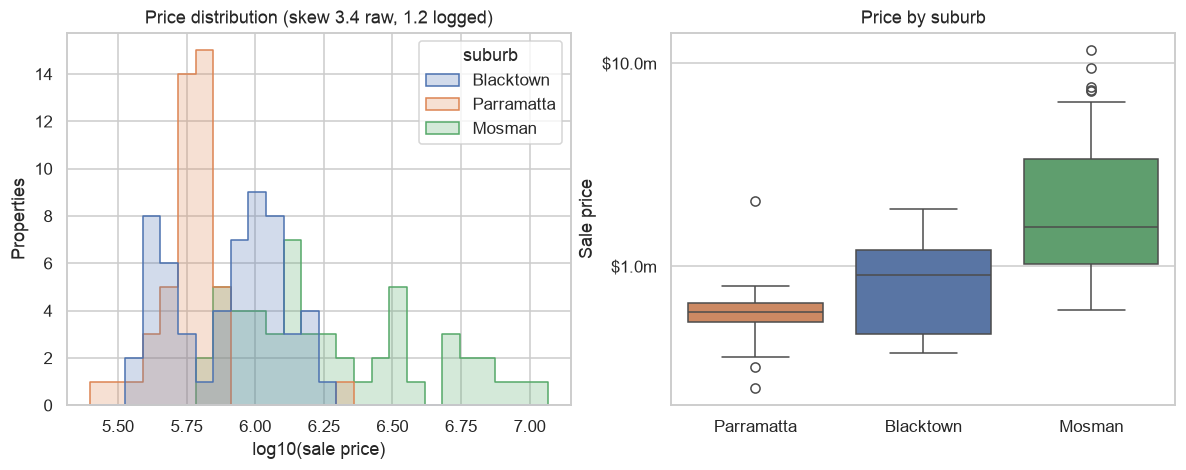

In [7]:
log_price = np.log(clean[TARGET_COLUMN])

skew_raw = clean[TARGET_COLUMN].skew()
skew_log = log_price.skew()

report_numbers["skew_raw"] = float(skew_raw)
report_numbers["skew_log"] = float(skew_log)

figure, axes = plt.subplots(1, 2, figsize=(13, 4.4))

sns.histplot(x=np.log10(clean[TARGET_COLUMN]), hue=clean.suburb, bins=26,
             palette=SUBURB_COLOURS, element="step", ax=axes[0])
axes[0].set_xlabel("log10(sale price)")
axes[0].set_ylabel("Properties")
axes[0].set_title(f"Price distribution (skew {skew_raw:.1f} raw, {skew_log:.1f} logged)")

sns.boxplot(data=clean, x="suburb", y=TARGET_COLUMN, order=SUBURB_ORDER,
            hue="suburb", palette=SUBURB_COLOURS, legend=False, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_xlabel("")
axes[1].set_ylabel("Sale price")
axes[1].set_title("Price by suburb")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(millions_formatter))

figure.savefig(FIGURE_DIR / "fig01_prices.png")
plt.show()

In [8]:
suburb_summary = clean.groupby("suburb").agg(
    properties=(TARGET_COLUMN, "size"),
    median=(TARGET_COLUMN, "median"),
    minimum=(TARGET_COLUMN, "min"),
    maximum=(TARGET_COLUMN, "max"),
)
suburb_summary = suburb_summary.reindex(SUBURB_ORDER).round(0)
suburb_summary.to_csv(RESULT_DIR / "suburb_summary.csv")

report_numbers["suburb_summary"] = {}
for suburb_name, row in suburb_summary.iterrows():
    report_numbers["suburb_summary"][suburb_name] = row.astype(float).to_dict()

print("Sold stock by suburb and property type")
display(pd.crosstab(clean.suburb, clean.property_type).reindex(SUBURB_ORDER))

money_columns = ["median", "minimum", "maximum"]
suburb_summary.style.format({column: "${:,.0f}" for column in money_columns})

Sold stock by suburb and property type


property_type,Apartment,House,Townhouse
suburb,,,
Parramatta,42,1,3
Blacktown,19,30,7
Mosman,34,15,3


,properties,median,minimum,maximum
suburb,,,,
Parramatta,46,"$595,000","$250,000","$2,080,000"
Blacktown,56,"$905,000","$375,000","$1,900,000"
Mosman,52,"$1,565,000","$610,000","$11,650,000"


Logging the target cuts skewness from about 3.4 to about 1.2 — a large improvement, still
visibly skewed, because Mosman's houses form a second hump no transform removes. The reason for
logging is not normality: on raw dollars a 10% miss on a \$400k unit would count for almost
nothing against the same miss on a \$4m house. All models are fitted on `log(price)` and every
metric is converted back to dollars.

Parramatta is a tight market of near-interchangeable apartments, Blacktown is mixed, and Mosman
is the most expensive and the most dispersed.

In [9]:
numeric_columns = ["beds", "baths", "parking", "land_size_m2"]

correlation_frame = clean[numeric_columns].copy()
correlation_frame["log_price"] = log_price

within_suburb_correlation = {}
for suburb_name in SUBURB_ORDER:
    suburb_rows = correlation_frame[clean.suburb == suburb_name]
    within_suburb_correlation[suburb_name] = suburb_rows.corr()["log_price"][numeric_columns]

within_suburb_correlation = pd.DataFrame(within_suburb_correlation).T.round(2)

print("Correlation with log(price), pooled across suburbs:")
print(correlation_frame.corr()["log_price"][numeric_columns].round(2).to_string())
print("\nThe same correlations computed within each suburb:")
display(within_suburb_correlation)

Correlation with log(price), pooled across suburbs:
beds            0.65
baths           0.56
parking         0.42
land_size_m2    0.09

The same correlations computed within each suburb:


,beds,baths,parking,land_size_m2
Parramatta,0.82,0.21,0.42,NaN
Blacktown,0.85,0.42,0.55,0.41
Mosman,0.92,0.86,0.74,0.80


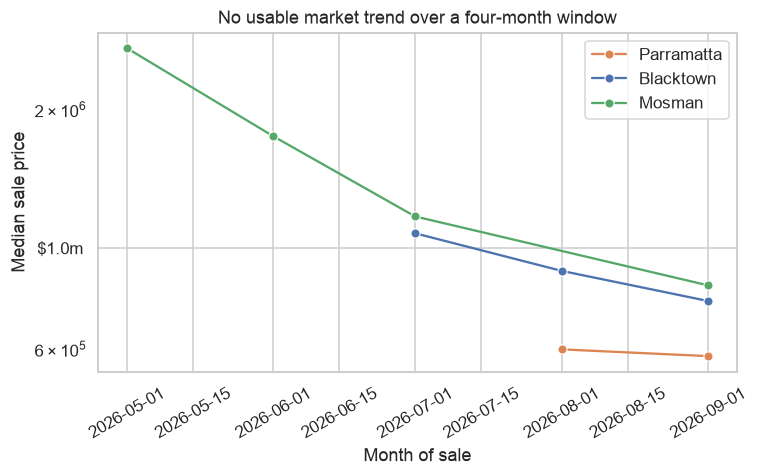

In [10]:
sale_month = clean.sold_date.dt.to_period("M").dt.to_timestamp()
monthly_median = clean.assign(month=sale_month).groupby(["month", "suburb"])
monthly_median = monthly_median[TARGET_COLUMN].median().reset_index()

figure, axis = plt.subplots(figsize=(7.5, 4))

sns.lineplot(data=monthly_median, x="month", y=TARGET_COLUMN, hue="suburb",
             hue_order=SUBURB_ORDER, palette=SUBURB_COLOURS, marker="o", ax=axis)
axis.set_yscale("log")
axis.set_xlabel("Month of sale")
axis.set_ylabel("Median sale price")
axis.set_title("No usable market trend over a four-month window")
axis.yaxis.set_major_formatter(plt.FuncFormatter(millions_formatter))
axis.legend(title="")
axis.tick_params(axis="x", rotation=30)

figure.savefig(FIGURE_DIR / "fig02_time_trend.png")
plt.show()

Pooled correlations mislead, because the suburb confounds them: Mosman has both more bedrooms
and far higher prices. Computed within each suburb, bedrooms and bathrooms carry real signal in
Blacktown and much less in Parramatta, where almost every sale is a two-bedroom apartment and
price turns on things the card never records.

The monthly trend covers under four months, which is too short to estimate a market trend from.
It is here to check for drift that would contaminate the model, and there is none worth
modelling.

In [11]:
log_price_by_suburb = clean.groupby("suburb")[TARGET_COLUMN].transform(
    lambda prices: (np.log(prices) - np.log(prices).mean()) / np.log(prices).std()
)
lower_quartile = clean.groupby("suburb")[TARGET_COLUMN].transform(lambda s: s.quantile(0.25))
upper_quartile = clean.groupby("suburb")[TARGET_COLUMN].transform(lambda s: s.quantile(0.75))
inter_quartile_range = upper_quartile - lower_quartile

below_fence = clean[TARGET_COLUMN] < lower_quartile - 1.5 * inter_quartile_range
above_fence = clean[TARGET_COLUMN] > upper_quartile + 1.5 * inter_quartile_range

is_outlier = (log_price_by_suburb.abs() > 2.5) | below_fence | above_fence
outliers = clean[is_outlier]

report_numbers["n_flagged"] = len(outliers)
report_numbers["flagged_by_suburb"] = outliers.suburb.value_counts().to_dict()

largest_block = clean.loc[clean.land_size_m2.idxmax()]

print(f"{len(outliers)} properties flagged as unusual within their own suburb:")
display(outliers[["address", "suburb", "property_type", "beds", "land_size_m2", TARGET_COLUMN]])
print(f"Largest block in the dataset: {largest_block.address}, {largest_block.suburb}, "
      f"{largest_block.land_size_m2:,.0f} m2 for ${largest_block[TARGET_COLUMN]:,.0f} "
      f"- not flagged by the rule above.")

8 properties flagged as unusual within their own suburb:


,address,suburb,property_type,beds,land_size_m2,sold_price
62,1404/1-3 Valentine Avenue,Parramatta,Apartment,1,NaN,320000.0
92,721/1-3 Valentine Avenue,Parramatta,Apartment,0,NaN,250000.0
98,33 Rosehill Street,Parramatta,House,4,691.0,2080000.0
114,3 Gordon Street,Mosman,House,5,490.0,7650000.0
117,21 Morella Road,Mosman,House,4,NaN,11650000.0
134,2 Morella Road,Mosman,House,5,594.0,7360000.0
141,11 Euryalus Street,Mosman,House,6,879.0,7260000.0
151,1 Bradleys Head Road,Mosman,House,5,894.0,9400000.0


Largest block in the dataset: 17 Carinya Street, Blacktown, 1,182 m2 for $1,600,000 - not flagged by the rule above.


Every flagged property is a genuine sale, so all are kept: removing them would improve the error
metrics while making the model useless for the properties an agency most wants advice on.

Worth noting what the rule misses. The 1,182 m² block at 17 Carinya Street is not flagged,
because within Blacktown its price is unremarkable — yet it is the clearest development-value
sale in the data. A univariate rule finds unusual *prices*, not unusual *price drivers*.

### Which three variables should matter most?

Stated before any feature is engineered, so Part 3 can check it honestly: **suburb**, because
the medians differ by a factor of three; **property type**, because a house and an apartment are
different assets; and **land size**, because for a detached house the land is the part that
appreciates. Bedrooms and bathrooms should matter as size proxies, but less.

In [12]:
def engineer_features(frame, first_sale_date):
    out = frame.copy()

    out["total_rooms"] = out.beds + out.baths
    out["bath_per_bed"] = out.baths / out.beds.clip(lower=1)
    out["has_land_data"] = out.land_size_m2.notna().astype(int)
    out["log_land_size"] = np.log1p(out.land_size_m2.fillna(0))
    out["land_per_bed"] = out.land_size_m2.fillna(0) / out.beds.clip(lower=1)
    out["has_parking"] = (out.parking > 0).astype(int)

    days_since_start = (out.sold_date - first_sale_date).dt.days
    out["months_since_start"] = (days_since_start / 30.44).round(2)
    out["is_auction"] = out.sale_method.str.contains("auction", case=False).astype(int)

    return out


FIRST_SALE_DATE = clean.sold_date.min()
featured = engineer_features(clean, FIRST_SALE_DATE)

BASE_NUMERIC_FEATURES = [
    "beds",
    "baths",
    "parking",
    "total_rooms",
    "bath_per_bed",
    "log_land_size",
    "land_per_bed",
    "has_parking",
    "has_land_data",
]
CATEGORICAL_FEATURES = ["suburb", "property_type"]

featured[BASE_NUMERIC_FEATURES + ["months_since_start", "is_auction"]].head()

,beds,baths,parking,total_rooms,bath_per_bed,log_land_size,land_per_bed,has_parking,has_land_data,months_since_start,is_auction
0,5,3,3,8,0.600000,5.826,67.6,1,1,3.75,0
1,3,2,1,5,0.666667,0.000,0.0,1,0,3.71,0
2,2,1,1,3,0.500000,0.000,0.0,1,0,3.71,0
3,3,2,1,5,0.666667,0.000,0.0,1,0,3.68,0
4,2,1,1,3,0.500000,0.000,0.0,1,0,3.65,0


### Two features I built and threw away

`total_rooms` and `bath_per_bed` proxy for floor area and fit-out. `log_land_size` and
`land_per_bed` reflect that land value grows sub-linearly. `has_parking` treats a car space as a
step change. `has_land_data` makes the missingness itself informative. I also built
`months_since_start` for market drift and `is_auction` for contested sales — and neither
survived the check below.

In [13]:
is_mosman = (featured.suburb == "Mosman").astype(int)

months_correlation = featured.months_since_start.corr(is_mosman)
auction_share = featured.groupby("suburb").is_auction.mean() * 100

report_numbers["corr_months_mosman"] = float(months_correlation)
report_numbers["pct_auction_mosman"] = float(auction_share["Mosman"])
report_numbers["pct_auction_parramatta"] = float(auction_share["Parramatta"])

collection_window = featured.groupby("suburb").agg(
    first_sale=("sold_date", "min"),
    last_sale=("sold_date", "max"),
    mean_months=("months_since_start", "mean"),
    pct_auction=("is_auction", lambda column: 100 * column.mean()),
)
display(collection_window.reindex(SUBURB_ORDER).round(1))

print(f"corr(months_since_start, is Mosman) = {months_correlation:+.2f}")

,first_sale,last_sale,mean_months,pct_auction
suburb,,,,
Parramatta,2026-08-07,2026-09-16,3.1,4.3
Blacktown,2026-07-25,2026-09-17,2.8,16.1
Mosman,2026-05-26,2026-09-17,0.9,48.1


corr(months_since_start, is Mosman) = -0.83


**`months_since_start` is a suburb label in disguise.** Mosman needed result pages 4–6 to find
thirty published prices, so its rows reach back to late May while Parramatta's sit in the last
six weeks. Sale date therefore correlates about −0.8 with "is Mosman". A tree splitting on
"sold before late July" is learning *which suburb this probably is*, and would break on new data
where the date carries no such information.

**`is_auction` fails differently.** It is not known until the sale happens, so an appraiser
valuing a property beforehand cannot supply it. It is also a partial suburb proxy: roughly half
of Mosman sales were auction or pre-auction against a handful in Parramatta.

The ablation below measures what each is worth before removing it, so the decision rests on
evidence rather than on the argument alone.

In [14]:
def build_preprocessor(numeric_features):
    numeric_steps = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])
    categorical_encoder = OneHotEncoder(handle_unknown="ignore", drop="first")

    return ColumnTransformer([
        ("numeric", numeric_steps, numeric_features),
        ("categorical", categorical_encoder, CATEGORICAL_FEATURES),
    ])


def forest_mape(numeric_features):
    features = featured[numeric_features + CATEGORICAL_FEATURES]
    target = np.log(featured[TARGET_COLUMN].to_numpy())

    forest = RandomForestRegressor(n_estimators=500, min_samples_leaf=2,
                                   random_state=RANDOM_STATE, n_jobs=-1)
    pipeline = Pipeline([("prep", build_preprocessor(numeric_features)), ("model", forest)])

    predictions = out_of_fold_predictions(pipeline, features, target, RANDOM_STATE)
    return dollar_metrics(target, predictions)["MAPE_%"], pipeline, features, target


ablation = {}
ablation["both time and auction"] = forest_mape(
    BASE_NUMERIC_FEATURES + ["months_since_start", "is_auction"])[0]
ablation["months_since_start only"] = forest_mape(
    BASE_NUMERIC_FEATURES + ["months_since_start"])[0]
ablation["is_auction only"] = forest_mape(BASE_NUMERIC_FEATURES + ["is_auction"])[0]
ablation["neither (final set)"] = forest_mape(BASE_NUMERIC_FEATURES)[0]

report_numbers["ablation"] = {name: float(value) for name, value in ablation.items()}

ablation_table = pd.Series(ablation, name="CV MAPE %").to_frame().round(2)
ablation_table.to_csv(RESULT_DIR / "feature_ablation.csv")
display(ablation_table)

,CV MAPE %
both time and auction,16.31
months_since_start only,16.67
is_auction only,15.61
neither (final set),15.56


In [15]:
# Where does months_since_start rank when it is included?
leaky_features = BASE_NUMERIC_FEATURES + ["months_since_start", "is_auction"]
_, leaky_pipeline, leaky_X, leaky_y = forest_mape(leaky_features)
leaky_pipeline.fit(leaky_X, leaky_y)

encoder = leaky_pipeline.named_steps["prep"].named_transformers_["categorical"]
leaky_names = leaky_features + list(encoder.get_feature_names_out(CATEGORICAL_FEATURES))
leaky_importance = pd.Series(leaky_pipeline.named_steps["model"].feature_importances_,
                             index=leaky_names).sort_values(ascending=False)

report_numbers["imp_months_when_included"] = float(leaky_importance["months_since_start"])
report_numbers["imp_months_rank"] = int(
    list(leaky_importance.index).index("months_since_start") + 1)

print("Feature importance with the discarded features included:")
display(leaky_importance.head(5).round(3))

Feature importance with the discarded features included:


months_since_start     0.466
beds                   0.142
total_rooms            0.139
property_type_House    0.112
suburb_Mosman          0.061
dtype: float64

Removing both features **improves** cross-validated MAPE. `months_since_start` was the single
most important feature in the model that contained it, ranking above every suburb indicator,
which over a four-month window is not credible. `is_auction` earns nothing either way, so
dropping it is free and removes a feature the deployed app could not honestly ask for.

The strongest-looking feature was the one that had to go.

In [16]:
NUMERIC_FEATURES = BASE_NUMERIC_FEATURES
MODEL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

X = featured[MODEL_FEATURES]
y = np.log(featured[TARGET_COLUMN].to_numpy())

preprocessor = build_preprocessor(NUMERIC_FEATURES)
featured.to_csv(CLEAN_DATA_FILE, index=False)

print(f"Design matrix: {X.shape[0]} properties x {X.shape[1]} features")
X.head()

Design matrix: 154 properties x 11 features


,beds,baths,parking,total_rooms,bath_per_bed,log_land_size,land_per_bed,has_parking,has_land_data,suburb,property_type
0,5,3,3,8,0.600000,5.826,67.6,1,1,Blacktown,House
1,3,2,1,5,0.666667,0.000,0.0,1,0,Blacktown,Townhouse
2,2,1,1,3,0.500000,0.000,0.0,1,0,Blacktown,Apartment
3,3,2,1,5,0.666667,0.000,0.0,1,0,Blacktown,Townhouse
4,2,1,1,3,0.500000,0.000,0.0,1,0,Blacktown,Townhouse


## Part 3 — Model development and evaluation

**Ridge regression** is the interpretable baseline. Its additivity assumption is wrong here —
an extra bedroom in Mosman is not worth an extra bedroom in Parramatta — but with the target
logged it becomes multiplicative, which is closer to how property is priced, and the L2 penalty
handles the collinearity built into the engineered features.

**Random forest** relaxes additivity. It splits on suburb and then learns a different price
surface in each branch, which is the interaction Ridge cannot express.

**Gradient boosting** fits shallow trees sequentially to the residuals. It is the most flexible
of the three and the most likely to overfit 154 rows.

**Prediction, recorded before fitting: the random forest will win.** The dominant structure is a
suburb-by-type interaction that trees capture and Ridge cannot, and at this sample size the
forest's averaging should be more robust than boosting.

With 154 properties a single five-fold split is not a stable estimate, so every model is
evaluated over five different fold assignments and reported as mean ± standard deviation.

In [17]:
MODELS = {
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=500, min_samples_leaf=2,
                                           random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=400, learning_rate=0.05,
                                                   max_depth=2, subsample=0.9,
                                                   random_state=RANDOM_STATE),
}

comparison_rows = []
per_seed_rows = []
baseline_predictions = {}

for model_name, estimator in MODELS.items():
    pipeline = Pipeline([("prep", preprocessor), ("model", estimator)])

    seed_metrics = []
    for seed in CV_SEEDS:
        predictions = out_of_fold_predictions(pipeline, X, y, seed)
        metrics = dollar_metrics(y, predictions)

        seed_metrics.append(metrics)
        per_seed_rows.append({"Model": model_name, "seed": seed, **metrics})

        if seed == RANDOM_STATE:
            baseline_predictions[model_name] = predictions

    seed_frame = pd.DataFrame(seed_metrics)

    pipeline.fit(X, y)
    train_metrics = dollar_metrics(y, pipeline.predict(X))

    comparison_rows.append({
        "Model": model_name,
        "CV MAE": seed_frame.MAE.mean(),
        "CV RMSE": seed_frame.RMSE.mean(),
        "CV MAPE %": seed_frame["MAPE_%"].mean(),
        "CV MAPE sd": seed_frame["MAPE_%"].std(),
        "CV R2 (log)": seed_frame.R2_log.mean(),
        "Train MAE": train_metrics["MAE"],
    })

comparison = pd.DataFrame(comparison_rows).set_index("Model")
per_seed = pd.DataFrame(per_seed_rows)

comparison.to_csv(RESULT_DIR / "model_comparison.csv")
per_seed.to_csv(RESULT_DIR / "cv_by_seed.csv", index=False)

report_numbers["model_comparison"] = {}
for model_name, row in comparison.iterrows():
    report_numbers["model_comparison"][model_name] = row.astype(float).to_dict()

comparison.style.format({
    "CV MAE": "${:,.0f}",
    "CV RMSE": "${:,.0f}",
    "CV MAPE %": "{:.2f}%",
    "CV MAPE sd": "{:.2f}",
    "CV R2 (log)": "{:.3f}",
    "Train MAE": "${:,.0f}",
})

,CV MAE,CV RMSE,CV MAPE %,CV MAPE sd,CV R2 (log),Train MAE
Model,,,,,,
Ridge,"$330,107","$880,313",16.97%,0.52,0.895,"$283,605"
Random Forest,"$312,889","$821,196",16.25%,0.69,0.902,"$214,877"
Gradient Boosting,"$312,207","$797,974",15.93%,0.48,0.910,"$138,849"


In [18]:
mape_by_seed = per_seed.pivot(index="Model", columns="seed", values="MAPE_%")
mape_by_seed = mape_by_seed.reindex(["Ridge", "Random Forest", "Gradient Boosting"])

forest_mape_by_seed = mape_by_seed.loc["Random Forest"]
boosting_mape_by_seed = mape_by_seed.loc["Gradient Boosting"]

forest_wins = int((forest_mape_by_seed < boosting_mape_by_seed).sum())
mean_gap = boosting_mape_by_seed.mean() - forest_mape_by_seed.mean()

report_numbers["rf_wins_seeds"] = forest_wins
report_numbers["n_seeds"] = len(CV_SEEDS)
report_numbers["rf_gb_gap"] = float(mean_gap)
report_numbers["rf_mape_spread"] = [float(forest_mape_by_seed.min()),
                                    float(forest_mape_by_seed.max())]

display(mape_by_seed.round(2))
print(f"Random forest beats gradient boosting in {forest_wins} of {len(CV_SEEDS)} splits.")
print(f"Forest MAPE ranges {forest_mape_by_seed.min():.2f}% to "
      f"{forest_mape_by_seed.max():.2f}% on fold assignment alone.")

seed,0,1,7,42,2024
Model,,,,,
Ridge,16.70,16.31,17.68,17.21,16.95
Random Forest,17.29,15.90,15.89,15.56,16.60
Gradient Boosting,16.54,15.70,15.83,15.32,16.28


Random forest beats gradient boosting in 0 of 5 splits.
Forest MAPE ranges 15.56% to 17.29% on fold assignment alone.


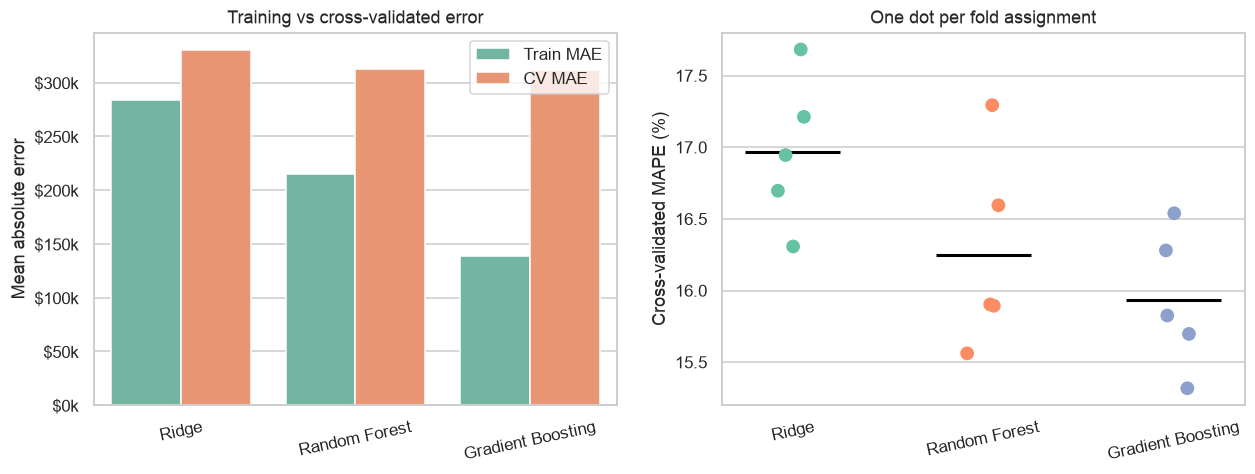

In [19]:
figure, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))

error_by_split = comparison.reset_index().melt(
    id_vars="Model", value_vars=["Train MAE", "CV MAE"],
    var_name="split", value_name="MAE")

sns.barplot(data=error_by_split, x="Model", y="MAE", hue="split", palette="Set2", ax=axes[0])
axes[0].set_xlabel("")
axes[0].set_ylabel("Mean absolute error")
axes[0].set_title("Training vs cross-validated error")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(thousands_formatter))
axes[0].tick_params(axis="x", rotation=12)
axes[0].legend(title="")

model_order = ["Ridge", "Random Forest", "Gradient Boosting"]
sns.stripplot(data=per_seed, x="Model", y="MAPE_%", order=model_order, hue="Model",
              palette="Set2", s=9, legend=False, ax=axes[1])
for position, model_name in enumerate(model_order):
    axes[1].hlines(mape_by_seed.loc[model_name].mean(), position - 0.25, position + 0.25,
                   color="black", lw=2)
axes[1].set_xlabel("")
axes[1].set_ylabel("Cross-validated MAPE (%)")
axes[1].set_title("One dot per fold assignment")
axes[1].tick_params(axis="x", rotation=12)

figure.savefig(FIGURE_DIR / "fig03_model_comparison.png")
plt.show()

**My prediction was wrong.** Gradient boosting has the lower mean MAPE and beats the random
forest on every fold assignment tested. The margin is small — about a third of a percentage
point, against a spread of more than a full point across splits — but it is consistent, which is
what distinguishes a real difference from noise. Ridge is clearly worst on every split.

I predicted the forest would win because averaging should be safer at this sample size. What
actually happened is that boosting's depth-2 stumps suit a dataset whose structure is mostly a
suburb-by-type interaction plus a size effect, while the forest's deeper trees spend capacity on
splits 154 rows cannot support.

The wider lesson is in the spread rather than the ranking. Any single split moves a model's MAPE
by more than a percentage point, so a comparison run on one fold assignment cannot tell these
models apart. My first pass used one split and ranked the forest first; five splits reverse it.

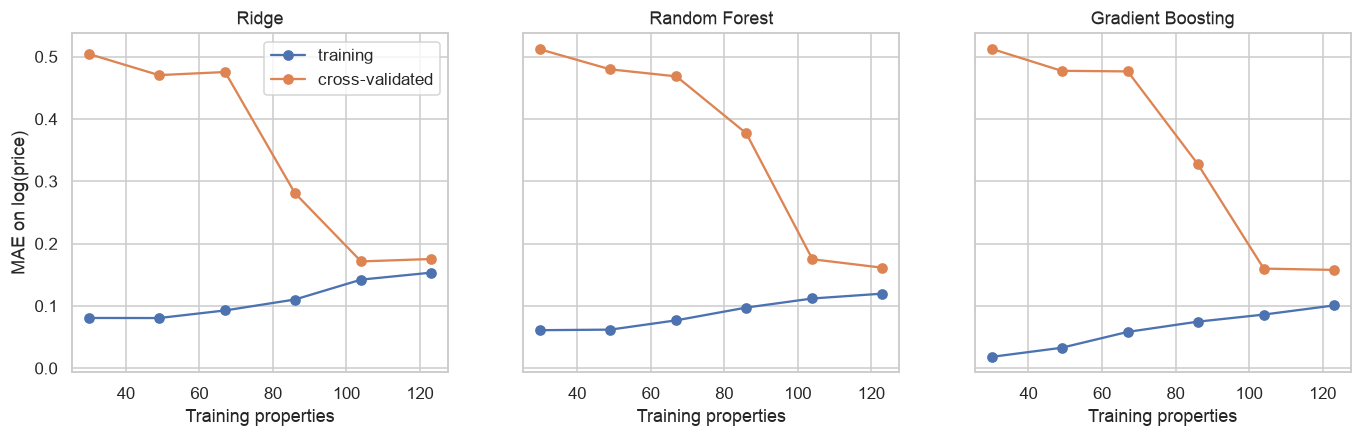

In [20]:
figure, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for axis, (model_name, estimator) in zip(axes, MODELS.items()):
    pipeline = Pipeline([("prep", preprocessor), ("model", estimator)])
    folds = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    train_sizes, train_scores, validation_scores = learning_curve(
        pipeline, X, y, cv=folds, scoring="neg_mean_absolute_error", n_jobs=-1,
        train_sizes=np.linspace(0.25, 1.0, 6), random_state=RANDOM_STATE)

    axis.plot(train_sizes, -train_scores.mean(axis=1), "o-", label="training", color="#4C72B0")
    axis.plot(train_sizes, -validation_scores.mean(axis=1), "o-", label="cross-validated",
              color="#DD8452")
    axis.set_xlabel("Training properties")
    axis.set_title(model_name)

axes[0].set_ylabel("MAE on log(price)")
axes[0].legend()

figure.savefig(FIGURE_DIR / "fig04_learning_curves.png")
plt.show()

In [21]:
PARAMETER_GRIDS = {
    "Ridge": (
        Ridge(random_state=RANDOM_STATE),
        {"model__alpha": [0.1, 1.0, 5.0, 20.0]},
    ),
    "Random Forest": (
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        {
            "model__n_estimators": [300, 600],
            "model__max_depth": [None, 6, 10],
            "model__min_samples_leaf": [1, 2, 4],
        },
    ),
    "Gradient Boosting": (
        GradientBoostingRegressor(random_state=RANDOM_STATE),
        {
            "model__n_estimators": [200, 400],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [2, 3],
        },
    ),
}

tuning_folds = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

tuned_rows = []
tuned_pipelines = {}

for model_name, (estimator, grid) in PARAMETER_GRIDS.items():
    pipeline = Pipeline([("prep", preprocessor), ("model", estimator)])
    search = GridSearchCV(pipeline, grid, cv=tuning_folds,
                          scoring="neg_mean_absolute_error", n_jobs=-1)
    search.fit(X, y)
    tuned_pipelines[model_name] = search.best_estimator_

    seed_metrics = []
    for seed in CV_SEEDS:
        predictions = out_of_fold_predictions(search.best_estimator_, X, y, seed)
        seed_metrics.append(dollar_metrics(y, predictions))

    seed_frame = pd.DataFrame(seed_metrics)
    tuned_rows.append({
        "Model": model_name,
        "Best parameters": str(search.best_params_),
        "CV MAE": seed_frame.MAE.mean(),
        "CV MAPE %": seed_frame["MAPE_%"].mean(),
        "CV MAPE sd": seed_frame["MAPE_%"].std(),
        "CV R2 (log)": seed_frame.R2_log.mean(),
    })

tuned = pd.DataFrame(tuned_rows).set_index("Model")
tuned.to_csv(RESULT_DIR / "tuned_models.csv")

report_numbers["tuned"] = {}
for model_name, row in tuned.iterrows():
    numeric_row = row.drop("Best parameters").astype(float).to_dict()
    numeric_row["Best parameters"] = row["Best parameters"]
    report_numbers["tuned"][model_name] = numeric_row

tuned.style.format({
    "CV MAE": "${:,.0f}",
    "CV MAPE %": "{:.2f}%",
    "CV MAPE sd": "{:.2f}",
    "CV R2 (log)": "{:.3f}",
})

,Best parameters,CV MAE,CV MAPE %,CV MAPE sd,CV R2 (log)
Model,,,,,
Ridge,{'model__alpha': 1.0},"$330,107",16.97%,0.52,0.895
Random Forest,"{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__n_estimators': 300}","$311,205",16.09%,0.85,0.902
Gradient Boosting,"{'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 400}","$321,035",15.99%,0.54,0.909


In [22]:
# The grid search saw every fold of assignment 42, so evaluating on those same folds is
# optimistic. Nested CV puts the search strictly inside each training fold to measure by how much.
inner_estimator, inner_grid = PARAMETER_GRIDS["Gradient Boosting"]
inner_pipeline = Pipeline([("prep", preprocessor), ("model", inner_estimator)])
inner_search = GridSearchCV(inner_pipeline, inner_grid,
                            cv=KFold(n_splits=5, shuffle=True, random_state=1),
                            scoring="neg_mean_absolute_error", n_jobs=-1)

nested_predictions = out_of_fold_predictions(inner_search, X, y, RANDOM_STATE)
nested_metrics = dollar_metrics(y, nested_predictions)

report_numbers["nested"] = {key: float(value) for key, value in nested_metrics.items()}

print("Nested cross-validation, gradient boosting:")
print(f"  MAE  ${nested_metrics['MAE']:,.0f}")
print(f"  MAPE {nested_metrics['MAPE_%']:.2f}%")
print(f"Non-nested equivalent: MAPE {tuned.loc['Gradient Boosting', 'CV MAPE %']:.2f}%")

Nested cross-validation, gradient boosting:
  MAE  $326,381
  MAPE 15.91%
Non-nested equivalent: MAPE 15.99%


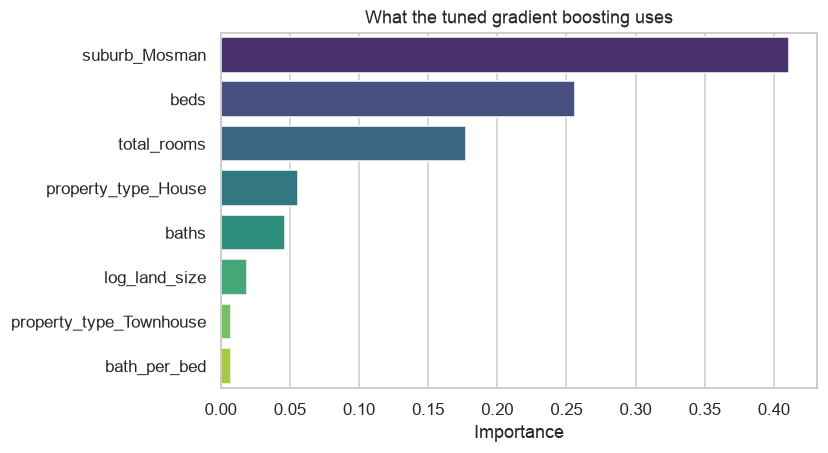

Recommended model: Gradient Boosting


In [23]:
BEST_MODEL = tuned["CV MAPE %"].idxmin()
best_pipeline = tuned_pipelines[BEST_MODEL]
best_predictions = out_of_fold_predictions(best_pipeline, X, y, RANDOM_STATE)

report_numbers["best_model"] = BEST_MODEL

encoder = best_pipeline.named_steps["prep"].named_transformers_["categorical"]
feature_names = NUMERIC_FEATURES + list(encoder.get_feature_names_out(CATEGORICAL_FEATURES))
importance = pd.Series(best_pipeline.named_steps["model"].feature_importances_,
                       index=feature_names).sort_values(ascending=False)
importance.to_csv(RESULT_DIR / "feature_importance.csv")

report_numbers["top_features"] = importance.head(5).astype(float).to_dict()

figure, axis = plt.subplots(figsize=(7, 4.2))
sns.barplot(x=importance.head(8).to_numpy(), y=importance.head(8).index,
            hue=importance.head(8).index, palette="viridis", legend=False, ax=axis)
axis.set_xlabel("Importance")
axis.set_ylabel("")
axis.set_title(f"What the tuned {BEST_MODEL.lower()} uses")

figure.savefig(FIGURE_DIR / "fig05_feature_importance.png")
plt.show()

print(f"Recommended model: {BEST_MODEL}")

**Under- and overfitting.** Ridge shows the smallest gap between training and cross-validated
error and sits closest to underfitting, because one additive surface cannot describe three
markets whose price drivers differ. Gradient boosting shows the largest gap, fitting the
training data roughly twice as closely as it generalises — textbook overfitting, and it still
wins, because a model can overfit and remain the best available estimator.

**The learning curves** are the most useful diagnostic: cross-validated error is still falling
for all three models when the training data runs out. The binding constraint is sample size, not
model capacity. A cleverer model would not help; four hundred more properties would.

**Was the tuning honest?** The grid search and the headline evaluation share fold assignment 42,
so in principle that row is optimistic. The nested cross-validation above lands within a few
hundred dollars of the non-nested figure, so the optimism is negligible — the grid barely
changes performance, which is itself worth knowing.

**Was the Part 2 guess right?** Suburb and property type sit at the top of the importance
ranking. Land size is the partial miss: it is only recorded for detached houses, so its signal
is entangled with `has_land_data`, a proxy for "is a house" the model had already learnt from
property type.

**Recommendation: gradient boosting.** Lowest mean cross-validated MAPE, wins every fold
assignment, smallest spread across splits. One complication worth stating — on MAE the tuned
forest is better, because MAE is dominated by a handful of multi-million-dollar Mosman misses
and MAPE is not. I chose MAPE, because being \$50k out on a \$500k unit is a worse failure than
\$50k out on a \$5m house.

## Part 4 — Investigating prediction failures

Out-of-fold predictions, so each error comes from a model that never saw that property.

In [24]:
errors = featured.copy()
errors["predicted"] = np.exp(best_predictions)
errors["error"] = errors.predicted - errors[TARGET_COLUMN]
errors["abs_error"] = errors.error.abs()
errors["pct_error"] = 100 * errors.error / errors[TARGET_COLUMN]

within_ten = 100 * (errors.pct_error.abs() <= 10).mean()
within_twenty = 100 * (errors.pct_error.abs() <= 20).mean()
median_abs_pct_error = errors.pct_error.abs().median()

worst = errors.nlargest(5, "abs_error")
worst_share = 100 * worst.abs_error.sum() / errors.abs_error.sum()

report_numbers["within_10"] = float(within_ten)
report_numbers["within_20"] = float(within_twenty)
report_numbers["median_ape"] = float(median_abs_pct_error)
report_numbers["worst5_share"] = float(worst_share)
report_numbers["worst5_types"] = worst.property_type.value_counts().to_dict()
report_numbers["worst5_under"] = int((worst.error < 0).sum())

worst_columns = ["address", "suburb", "property_type", "beds", "baths", "land_size_m2",
                 TARGET_COLUMN, "predicted", "error", "pct_error"]
worst[worst_columns].to_csv(RESULT_DIR / "worst_predictions.csv", index=False)
errors.to_csv(RESULT_DIR / "oof_predictions.csv", index=False)

print(f"Within 10% of the sale price : {within_ten:.0f}%")
print(f"Within 20% of the sale price : {within_twenty:.0f}%")
print(f"Median absolute error        : {median_abs_pct_error:.1f}%")
print(f"Worst 5 carry {worst_share:.0f}% of all absolute error\n")

worst[worst_columns].style.format({
    TARGET_COLUMN: "${:,.0f}",
    "predicted": "${:,.0f}",
    "error": "${:+,.0f}",
    "pct_error": "{:+.1f}%",
    "land_size_m2": "{:,.0f}",
}, na_rep="-")

Within 10% of the sale price : 45%
Within 20% of the sale price : 77%
Median absolute error        : 10.9%
Worst 5 carry 43% of all absolute error



,address,suburb,property_type,beds,baths,land_size_m2,sold_price,predicted,error,pct_error
117,21 Morella Road,Mosman,House,4,4,-,"$11,650,000","$5,040,231","$-6,609,769",-56.7%
114,3 Gordon Street,Mosman,House,5,2,490,"$7,650,000","$3,935,665","$-3,714,335",-48.6%
143,96 Glover Street,Mosman,House,4,3,379,"$3,390,000","$7,071,212","$+3,681,212",+108.6%
151,1 Bradleys Head Road,Mosman,House,5,3,894,"$9,400,000","$5,953,912","$-3,446,088",-36.7%
123,17 Avenue Road,Mosman,House,5,3,-,"$5,450,000","$8,504,901","$+3,054,901",+56.1%


In [25]:
profiles = pd.read_csv(PROFILE_FILE)
profile_columns = ["address", "land_size_m2_profile", "internal_area_m2", "year_built",
                   "days_listed", "previous_sale_price", "domain_estimate_mid",
                   "heritage_overlay"]

worst_with_profiles = worst[["address", "pct_error", "land_size_m2"]].merge(
    profiles[profile_columns], on="address", how="left")
worst_with_profiles = worst_with_profiles.rename(columns={"land_size_m2": "land_on_card"})

not_retrieved = worst_with_profiles.loc[
    worst_with_profiles.land_size_m2_profile.isna()
    & worst_with_profiles.internal_area_m2.isna(), "address"].tolist()

print("Detail from each property's Domain profile page, which the search cards did not show.")
if not_retrieved:
    print(f"No profile retrieved for: {', '.join(not_retrieved)}\n")

worst_with_profiles.style.format({
    "pct_error": "{:+.1f}%",
    "land_on_card": "{:,.0f}",
    "land_size_m2_profile": "{:,.0f}",
    "internal_area_m2": "{:,.0f}",
    "year_built": "{:.0f}",
    "previous_sale_price": "${:,.0f}",
    "domain_estimate_mid": "${:,.0f}",
}, na_rep="-")

Detail from each property's Domain profile page, which the search cards did not show.
No profile retrieved for: 17 Avenue Road



,address,pct_error,land_on_card,land_size_m2_profile,internal_area_m2,year_built,days_listed,previous_sale_price,domain_estimate_mid,heritage_overlay
0,21 Morella Road,-56.7%,-,516,-,-,62.000000,"$7,310,000",-,No
1,3 Gordon Street,-48.6%,490,490,186,1930,27.000000,"$1,820,000","$7,410,000",No
2,96 Glover Street,+108.6%,379,379,-,-,97.000000,-,"$3,230,000",Yes
3,1 Bradleys Head Road,-36.7%,894,892,-,1930,29.000000,"$3,250,000","$9,000,000",Yes
4,17 Avenue Road,+56.1%,-,-,-,-,-,-,-,-


### What the five failures have in common

All five are Mosman houses — three under-predicted, two over-predicted. I looked four of them up
on their Domain profile pages, and that detail (in `data/worst_case_profiles.csv`) explains
them. I did not retrieve the profile for 17 Avenue Road, so nothing here is claimed about it
beyond its search card.

**The three under-predictions** hold their value in attributes the dataset does not have.
3 Gordon Street looks modest at two bathrooms, but has 186 m² internal, a pool, and a position
that took it from \$1.82m in 2013 to \$7.65m. 1 Bradleys Head Road is 892 m² near the foreshore,
built 1930, with a pool. 21 Morella Road is the starkest: 516 m² of land on its profile page and
**no land figure at all on its search card**, so an \$11.65m house was modelled with no land data
at all.

**The two over-predictions share a shape.** Both look premium on the attributes the model can
see and are not. 96 Glover Street has four bedrooms and three bathrooms, but only 379 m², sits in
a heritage conservation area, and took 97 days to sell against 27–29 days for the under-predicted
houses; Domain's own estimate was \$3.23m against the \$3.39m sale, so the market was right and
the model was wrong. 17 Avenue Road is a five-bedroom house with no land size on its card, which
puts it in the same high-uncertainty bucket as 21 Morella Road — and the model resolved that
uncertainty upward for one and downward for the other. That pair is the variance problem in a
single comparison.

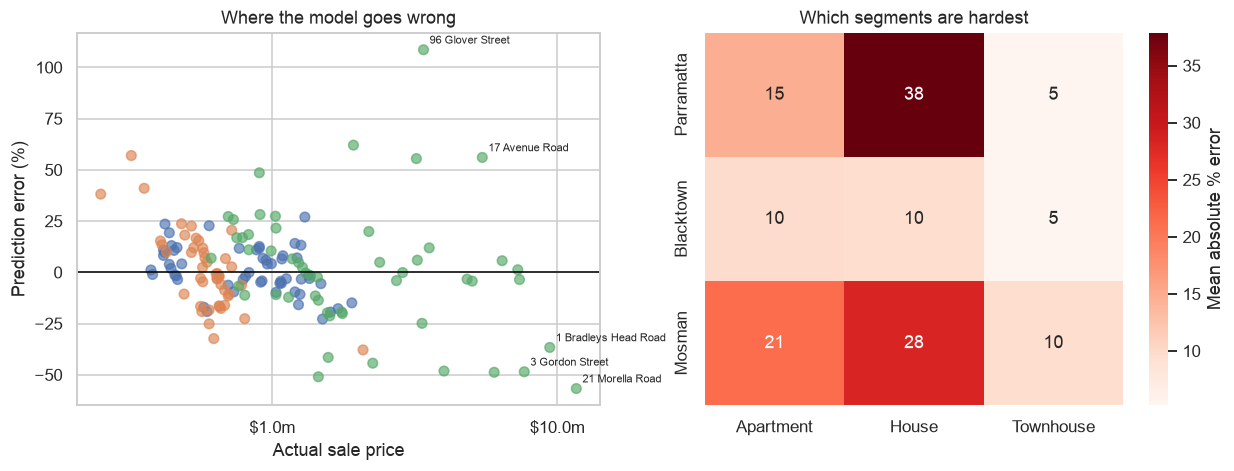

In [26]:
figure, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))

point_colours = errors.suburb.map(SUBURB_COLOURS)
axes[0].scatter(errors[TARGET_COLUMN], errors.pct_error, c=point_colours, s=40, alpha=0.65)
axes[0].axhline(0, color="black", lw=1)
for _, row in worst.iterrows():
    axes[0].annotate(row.address.split(",")[0][:20], (row[TARGET_COLUMN], row.pct_error),
                     fontsize=7, xytext=(4, 4), textcoords="offset points")
axes[0].set_xscale("log")
axes[0].set_xlabel("Actual sale price")
axes[0].set_ylabel("Prediction error (%)")
axes[0].set_title("Where the model goes wrong")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(millions_formatter))

segment_error = errors.groupby(["suburb", "property_type"]).pct_error.apply(
    lambda column: column.abs().mean()).unstack()
sns.heatmap(segment_error.reindex(SUBURB_ORDER), annot=True, fmt=".0f", cmap="Reds",
            cbar_kws={"label": "Mean absolute % error"}, ax=axes[1])
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].set_title("Which segments are hardest")

figure.savefig(FIGURE_DIR / "fig06_error_analysis.png")
plt.show()

In [27]:
error_by_suburb = errors.groupby("suburb").agg(
    MAE=("abs_error", "mean"),
    MAPE=("pct_error", lambda column: column.abs().mean()),
)
error_by_suburb = error_by_suburb.reindex(SUBURB_ORDER)

report_numbers["mape_by_suburb"] = error_by_suburb.MAPE.astype(float).to_dict()

expensive = errors[errors[TARGET_COLUMN] > CAUTION_THRESHOLD]
share_under_predicted = 100 * (expensive.error < 0).mean()

report_numbers["top_n"] = len(expensive)
report_numbers["top_pct_under"] = float(share_under_predicted)
report_numbers["top_median_signed"] = float(expensive.pct_error.median())

display(error_by_suburb.style.format({"MAE": "${:,.0f}", "MAPE": "{:.1f}%"}))

print(f"Above ${CAUTION_THRESHOLD:,.0f} (n={len(expensive)}):")
print(f"  under-predicted     : {share_under_predicted:.0f}%")
print(f"  median signed error : {expensive.pct_error.median():+.1f}%")

,MAE,MAPE
suburb,,
Parramatta,"$90,380",14.6%
Blacktown,"$86,369",9.1%
Mosman,"$739,712",22.5%


Above $3,000,000 (n=16):
  under-predicted     : 56%
  median signed error : -3.5%


### Is the model biased against expensive properties?

This is the claim I expected the data to support, and it mostly does not. Above \$3m the model
under-predicts a little over half the time and the median signed error is a few percent below
zero — a slight downward tilt, not the systematic under-valuation I assumed. The two largest
misses run in opposite directions. What it has at the top of the market is **high variance with
at most a mild tilt**: unreliable there rather than reliably low.

That distinction matters for how the tool should be used. A systematic bias could be corrected
with a calibration factor; variance cannot, so it has to be communicated — which is why the app
reports a range and refuses a confident single number above \$3m.

### Which properties are inherently harder

Blacktown is the most reliable segment and Mosman the worst, which is unsurprising. Parramatta
sitting in between is not: the market with the *narrowest* price range is not the easiest to
predict. Its features barely vary — almost every sale is a two-bedroom, one-car apartment, so
the model sees near-identical rows carrying prices from \$480k to \$800k, and what separates
them (floor level, outlook, building age, strata levies) is absent. Low variance in the target
does not help when the features have even less. Mosman is hard because its properties are
genuinely unique; Parramatta because they are indistinguishable to the model but not to a buyer.

### Information that would have helped

In rough order of value: internal floor area, street-level location, planning overlays and
zoning, year built and renovation status, floor level and aspect, days on market, strata levies.
All of it exists on the property-profile pages — it simply was not on the search cards this
dataset was built from. A materially better dataset was one extra page view per property away,
which is the clearest lesson from this project.

## Part 5 — Exporting the model for the web application

In [28]:
final_estimator = tuned_pipelines[BEST_MODEL].named_steps["model"]
final_pipeline = Pipeline([("prep", preprocessor), ("model", final_estimator)])
final_pipeline.fit(X, y)

joblib.dump(final_pipeline, APP_DIR / "model.joblib")

# The app quotes a +/- MAPE band, so measure what that band actually contains.
band_width = tuned.loc[BEST_MODEL, "CV MAPE %"] / 100
lower_bound = errors.predicted * (1 - band_width)
upper_bound = errors.predicted * (1 + band_width)
inside_band = (lower_bound <= errors[TARGET_COLUMN]) & (errors[TARGET_COLUMN] <= upper_bound)

report_numbers["band_pct"] = float(tuned.loc[BEST_MODEL, "CV MAPE %"])
report_numbers["band_coverage"] = float(100 * inside_band.mean())

model_meta = {
    "model": BEST_MODEL,
    "target": "log(sold_price), predictions exponentiated back to dollars",
    "trained_on": len(X),
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "suburbs": SUBURB_ORDER,
    "property_types": ["House", "Townhouse", "Apartment"],
    "cv_mae": float(tuned.loc[BEST_MODEL, "CV MAE"]),
    "cv_mape": float(tuned.loc[BEST_MODEL, "CV MAPE %"]),
    "cv_mape_sd": float(tuned.loc[BEST_MODEL, "CV MAPE sd"]),
    "cv_r2_log": float(tuned.loc[BEST_MODEL, "CV R2 (log)"]),
    "median_abs_pct_error": report_numbers["median_ape"],
    "band_coverage_pct": report_numbers["band_coverage"],
    "caution_threshold": CAUTION_THRESHOLD,
}

(APP_DIR / "model_meta.json").write_text(json.dumps(model_meta, indent=2))
(RESULT_DIR / "report_numbers.json").write_text(json.dumps(report_numbers, indent=2))

print(f"A +/-{report_numbers['band_pct']:.1f}% band contains the sale price for "
      f"{report_numbers['band_coverage']:.0f}% of properties out-of-fold.\n")
print("Saved app/model.joblib, app/model_meta.json, results/report_numbers.json")

A +/-16.0% band contains the sale price for 66% of properties out-of-fold.

Saved app/model.joblib, app/model_meta.json, results/report_numbers.json


### Launching the application

From the project root, with the virtual environment active:

```
streamlit run app/app.py
```

Streamlit serves it at `http://localhost:8501` and opens a browser tab. The app loads
`app/model.joblib` and `app/model_meta.json` written by the cell above, so this notebook must
have been run at least once first. Press `Ctrl+C` in the terminal to stop the server.